# 統計

## 線形回帰サンプル

<https://qiita.com/0NE_shoT_/items/08376b08783cd554b02e>

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
data = load_diabetes()

df_data = pd.DataFrame(data.data, columns=data.feature_names)
df_data['TARGET'] = data.target

In [2]:
df_data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
import plotly.express as px
fig = px.scatter(df_data, x='bmi', y='TARGET')
fig.show()

In [4]:
# 相関係数の確認
df_data[['bmi','TARGET']].corr()

,bmi,TARGET
bmi,1.00000,0.58645
TARGET,0.58645,1.00000


In [5]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
x = df_data[['bmi']].values
y = df_data[['TARGET']].values

model.fit(x, y)

LinearRegression()

In [6]:
print('coefficient = ', model.coef_[0]) # 説明変数の係数を出力
print('intercept = ', model.intercept_) # 切片を出力

coefficient =  [949.43526038]
intercept =  [152.13348416]


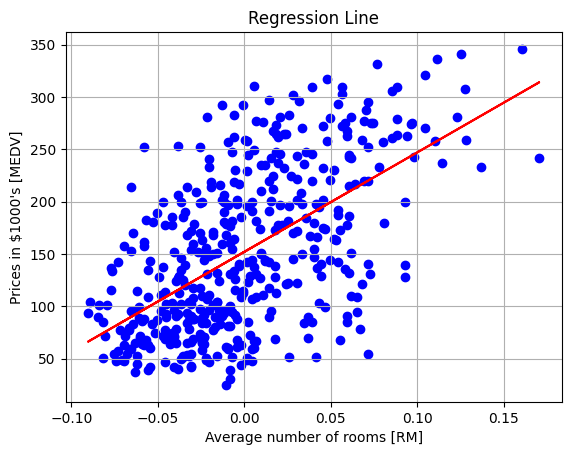

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(x, y, color = 'blue')         # 説明変数と目的変数のデータ点の散布図をプロット
plt.plot(x, model.predict(x), color = 'red') # 回帰直線をプロット

plt.title('Regression Line')               # 図のタイトル
plt.xlabel('Average number of rooms [RM]') # x軸のラベル
plt.ylabel('Prices in $1000\'s [MEDV]')    # y軸のラベル
plt.grid()                                 # グリッド線を表示

plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, train_size = 0.7, test_size = 0.3, random_state = 0) # データを学習用と検証用に分割

lr = LinearRegression()
lr.fit(X_train, Y_train) # 線形モデルの重みを学習

LinearRegression()

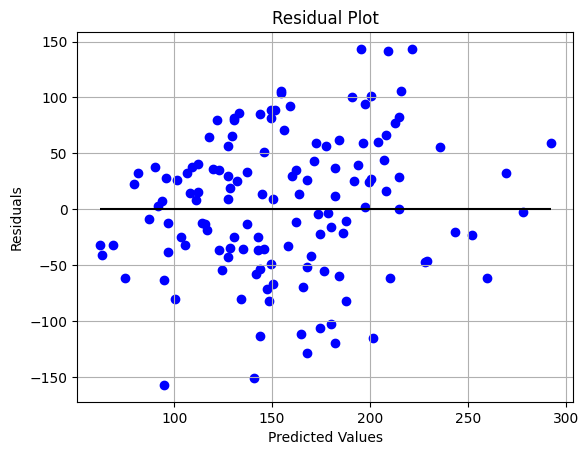

In [9]:
Y_pred = lr.predict(X_test) # 検証データを用いて目的変数を予測

# 残差=0が理想であり、0を中心にばらつくはず

plt.scatter(Y_pred, Y_pred - Y_test, color = 'blue')      # 残差をプロット
plt.hlines(y = 0, xmin = min(Y_pred), xmax = max(Y_pred), color = 'black') # x軸に沿った直線をプロット
plt.title('Residual Plot')                                # 図のタイトル
plt.xlabel('Predicted Values')                            # x軸のラベル
plt.ylabel('Residuals')                                   # y軸のラベル
plt.grid()                                                # グリッド線を表示

plt.show()

In [10]:
from sklearn.metrics import mean_squared_error

Y_train_pred = lr.predict(X_train) # 学習データに対する目的変数を予測
print('MSE train data: ', mean_squared_error(Y_train, Y_train_pred)) # 学習データを用いたときの平均二乗誤差を出力
print('MSE test data: ', mean_squared_error(Y_test, Y_pred)) # 検証データを用いたときの平均二乗誤差を出力
# 学習データの方が明らかに良い値の時は、過学習を疑うべき

MSE train data:  3892.7208150824304
MSE test data:  3921.3720274248517


In [11]:
X_test

array([[ 0.10480869],
       [ 0.06061839],
       [ 0.00888341],
       [-0.02345095],
       [ 0.04552903],
       [ 0.097264  ],
       [-0.02884001],
       [ 0.02289497],
       [ 0.05415152],
       [ 0.04660684],
       [-0.05794093],
       [ 0.04660684],
       [-0.0374625 ],
       [-0.046085  ],
       [ 0.08864151],
       [-0.02237314],
       [-0.05901875],
       [-0.05147406],
       [-0.08380842],
       [ 0.04013997],
       [ 0.02828403],
       [ 0.01103904],
       [-0.02452876],
       [ 0.05846277],
       [ 0.05522933],
       [ 0.01750591],
       [-0.04177375],
       [-0.04500719],
       [ 0.00457217],
       [ 0.02612841],
       [-0.00297252],
       [-0.05255187],
       [-0.0105172 ],
       [-0.01159501],
       [-0.00620595],
       [ 0.02073935],
       [-0.01590626],
       [-0.00943939],
       [ 0.00133873],
       [ 0.03367309],
       [-0.06548562],
       [-0.0105172 ],
       [-0.00728377],
       [-0.00405033],
       [ 0.03043966],
       [-0

In [12]:
# 学習モデルに、適当な値を入れてみる
import numpy as np
sample_data = np.array([[0]])
lr.predict(sample_data)

array([[153.43509039]])

In [14]:
import pickle
# モデルを保存
filename = 'save_model.pickle'
pickle.dump(lr, open(filename, 'wb'))

In [15]:
# 保存したモデルをロードする
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.predict(sample_data)
print(result)


[[153.43509039]]
